# TransferBench

# Experiment 3

## EfficientNet-B0 Feature Extraction

This notebook evaluates EfficientNet-B0 using transfer learning.

The backbone is frozen and only the classifier is trained.

Outputs

- Trained Model
- Metrics
- Curves
- Confusion Matrix

In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [4]:
import torch
import torch.nn as nn

from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from utils.dataset import load_dataset

from utils.models import build_model

from utils.training import (
    train_model,
    print_summary,
)

from utils.evaluation import (
    calculate_metrics,
    print_metrics,
    export_metrics_csv,
)

from utils.visualization import (
    plot_loss_curve,
    plot_accuracy_curve,
    plot_confusion_matrix,
)

from utils.paths import *

Import OK ✅


In [5]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


## Load Dataset

In [6]:
train_loader, test_loader, class_names = load_dataset(
    dataset_name="cifar10",
    batch_size=32,
    image_size=224,
)

C:\Users\pc1\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## Build EfficientNet-B0

In [7]:
model = build_model(
    model_name="efficientnet",
    num_classes=10,
    strategy="freeze",
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\pc1/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|█████████████████████████████████████████████████████████████████████████████| 20.5M/20.5M [00:17<00:00, 1.25MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

## Optimizer

In [8]:
criterion = nn.CrossEntropyLoss()

optimizer = Adam(

    filter(
        lambda p: p.requires_grad,
        model.parameters(),
    ),

    lr=1e-3,

)

In [9]:
scheduler = ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=0.5,

    patience=2,

)

In [10]:
EPOCHS = 20

checkpoint_path = get_model_path(
    "best_efficientnet_freeze"
)

print(checkpoint_path)

C:\Users\pc1\TransferBench\models\best_efficientnet_freeze.pth


## Train Model

In [11]:
results = train_model(

    model=model,

    train_loader=train_loader,

    val_loader=test_loader,

    criterion=criterion,

    optimizer=optimizer,

    scheduler=scheduler,

    epochs=EPOCHS,

    device=device,

    checkpoint_path=checkpoint_path,

)

Training Started
Epoch 01/20 | Train Loss: 0.9102 | Train Acc: 0.7068 | Val Loss: 0.5693 | Val Acc: 0.8179
Epoch 02/20 | Train Loss: 0.7690 | Train Acc: 0.7403 | Val Loss: 0.5200 | Val Acc: 0.8276
Epoch 03/20 | Train Loss: 0.7537 | Train Acc: 0.7438 | Val Loss: 0.5185 | Val Acc: 0.8276
Epoch 04/20 | Train Loss: 0.7469 | Train Acc: 0.7444 | Val Loss: 0.5307 | Val Acc: 0.8270
Epoch 05/20 | Train Loss: 0.7444 | Train Acc: 0.7453 | Val Loss: 0.5345 | Val Acc: 0.8219
Epoch 06/20 | Train Loss: 0.7345 | Train Acc: 0.7495 | Val Loss: 0.5307 | Val Acc: 0.8201
Epoch 07/20 | Train Loss: 0.7272 | Train Acc: 0.7527 | Val Loss: 0.5087 | Val Acc: 0.8324
Epoch 08/20 | Train Loss: 0.7248 | Train Acc: 0.7537 | Val Loss: 0.5024 | Val Acc: 0.8311
Epoch 09/20 | Train Loss: 0.7198 | Train Acc: 0.7546 | Val Loss: 0.5045 | Val Acc: 0.8301
Epoch 10/20 | Train Loss: 0.7319 | Train Acc: 0.7527 | Val Loss: 0.5029 | Val Acc: 0.8341
Epoch 11/20 | Train Loss: 0.7246 | Train Acc: 0.7536 | Val Loss: 0.5063 | Val Acc: 

# Model Evaluation

In [12]:
metrics = calculate_metrics(
    results["targets"],
    results["predictions"],
)

print_metrics(metrics)

Evaluation Results
Accuracy  : 0.8354
Precision : 0.8360
Recall    : 0.8354
F1 Score  : 0.8340


In [13]:
metrics_df = export_metrics_csv(
    metrics=metrics,
    model_name="EfficientNet-B0",
    strategy="Feature Extraction",
    training_time=results["training_time"],
    save_path=get_metrics_path("efficientnet_freeze"),
)

metrics_df

,Model,Strategy,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,EfficientNet-B0,Feature Extraction,0.8354,0.835958,0.8354,0.834041,3464.282269


# Learning Curves

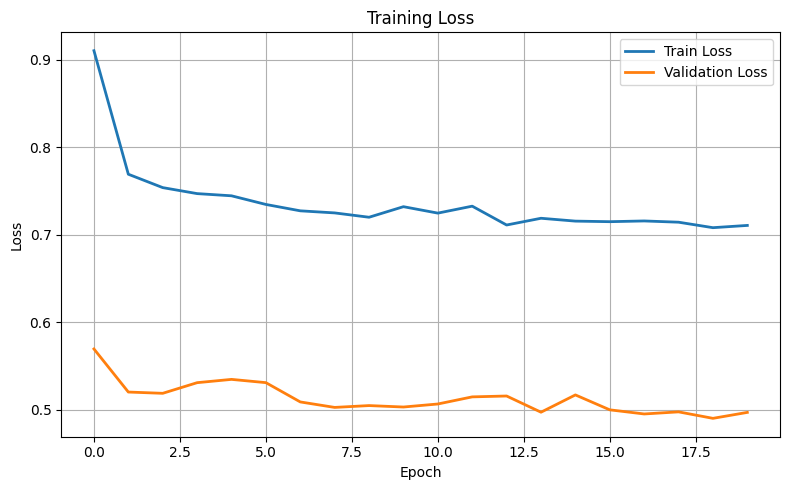

In [14]:
plot_loss_curve(
    history=results["history"],
    save_path=get_loss_plot_path("efficientnet_freeze"),
)

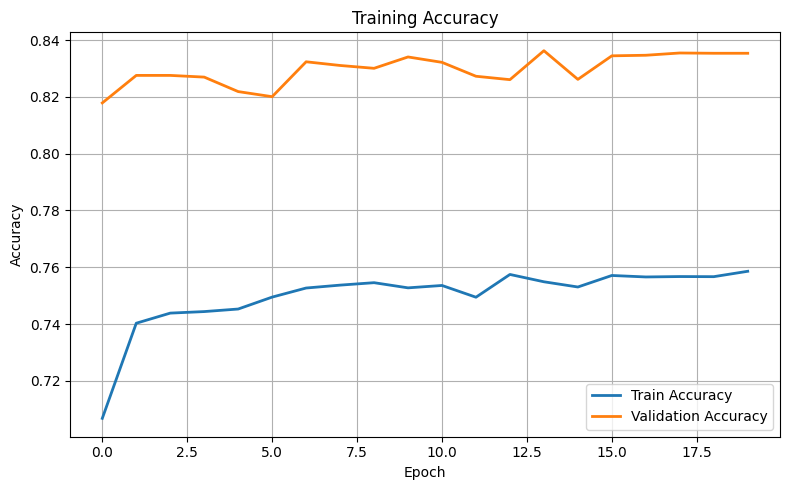

In [15]:
plot_accuracy_curve(
    history=results["history"],
    save_path=get_accuracy_plot_path("efficientnet_freeze"),
)

# Confusion Matrix

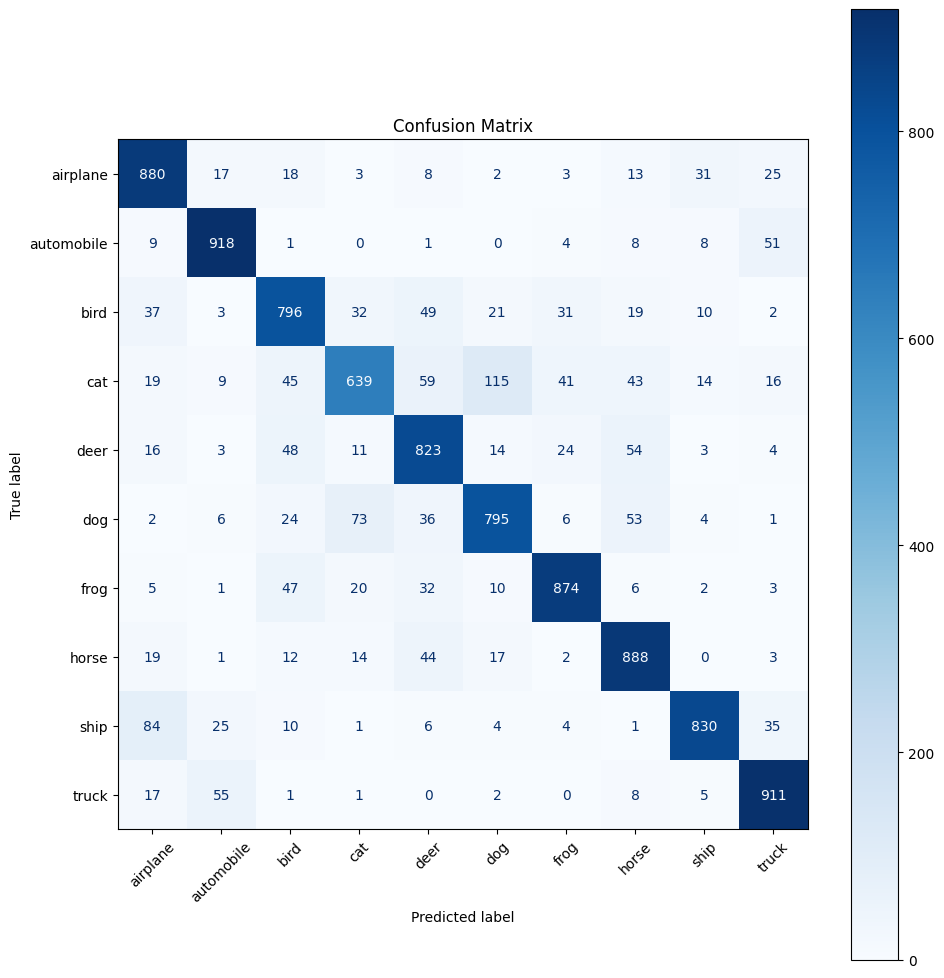

In [16]:
from utils.evaluation import build_confusion_matrix

cm = build_confusion_matrix(
    results["targets"],
    results["predictions"],
)

plot_confusion_matrix(
    matrix=cm,
    class_names=class_names,
    save_path=get_confusion_matrix_path("efficientnet_freeze"),
)

# Training Summary

In [17]:
print_summary(results)



Training Summary
Best Accuracy : 0.8363
Training Time : 3464.28 sec
Checkpoint    : C:\Users\pc1\TransferBench\models\best_efficientnet_freeze.pth


In [18]:
metrics_df

,Model,Strategy,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,EfficientNet-B0,Feature Extraction,0.8354,0.835958,0.8354,0.834041,3464.282269


In [19]:
results["history"]

{'train_loss': [0.9102450308227539,
  0.7690232374191284,
  0.7537192250442505,
  0.7468653441715241,
  0.7443570423126221,
  0.7344704814147949,
  0.7271758296680451,
  0.7247946176147461,
  0.7198381369400024,
  0.731914560623169,
  0.7245649333763122,
  0.732505455083847,
  0.7109665383720398,
  0.7186749773788452,
  0.7154155681991577,
  0.7147628981781006,
  0.7156012730979919,
  0.7141807282447815,
  0.7079088837432861,
  0.7104910719680786],
 'train_acc': [0.70676,
  0.74028,
  0.74384,
  0.74438,
  0.74528,
  0.74948,
  0.75268,
  0.7537,
  0.75456,
  0.75274,
  0.75358,
  0.74944,
  0.75746,
  0.75488,
  0.75304,
  0.7571,
  0.75658,
  0.75672,
  0.75668,
  0.75858],
 'val_loss': [0.569253520822525,
  0.5199859333992004,
  0.5185304619312286,
  0.5306919631958008,
  0.534462695646286,
  0.5307248143672944,
  0.5086767961978912,
  0.502412306213379,
  0.5045139242649078,
  0.502859185218811,
  0.5063203491687774,
  0.5144635129928589,
  0.5154523849964142,
  0.49693392310142515

In [20]:
results

{'history': {'train_loss': [0.9102450308227539,
   0.7690232374191284,
   0.7537192250442505,
   0.7468653441715241,
   0.7443570423126221,
   0.7344704814147949,
   0.7271758296680451,
   0.7247946176147461,
   0.7198381369400024,
   0.731914560623169,
   0.7245649333763122,
   0.732505455083847,
   0.7109665383720398,
   0.7186749773788452,
   0.7154155681991577,
   0.7147628981781006,
   0.7156012730979919,
   0.7141807282447815,
   0.7079088837432861,
   0.7104910719680786],
  'train_acc': [0.70676,
   0.74028,
   0.74384,
   0.74438,
   0.74528,
   0.74948,
   0.75268,
   0.7537,
   0.75456,
   0.75274,
   0.75358,
   0.74944,
   0.75746,
   0.75488,
   0.75304,
   0.7571,
   0.75658,
   0.75672,
   0.75668,
   0.75858],
  'val_loss': [0.569253520822525,
   0.5199859333992004,
   0.5185304619312286,
   0.5306919631958008,
   0.534462695646286,
   0.5307248143672944,
   0.5086767961978912,
   0.502412306213379,
   0.5045139242649078,
   0.502859185218811,
   0.5063203491687774,
   

In [22]:
print("=" * 60)

print("Saved Model")
print(get_model_path("best_efficientnet_freeze"))

print()

print("Metrics CSV")
print(get_metrics_path("efficientnet_freeze"))

print()

print("Loss Curve")
print(get_loss_plot_path("efficientnet_freeze"))

print()

print("Accuracy Curve")
print(get_accuracy_plot_path("efficientnet_freeze"))

print()

print("Confusion Matrix")
print(get_confusion_matrix_path("efficientnet_freeze"))

print("=" * 60)

Saved Model
C:\Users\pc1\TransferBench\models\best_efficientnet_freeze.pth

Metrics CSV
C:\Users\pc1\TransferBench\results\efficientnet_freeze_metrics.csv

Loss Curve
C:\Users\pc1\TransferBench\figures\efficientnet_freeze_loss.png

Accuracy Curve
C:\Users\pc1\TransferBench\figures\efficientnet_freeze_accuracy.png

Confusion Matrix
C:\Users\pc1\TransferBench\figures\confusion_matrix_efficientnet_freeze.png


In [23]:
from pathlib import Path

print("========== MODELS ==========")
for f in sorted(Path(MODEL_DIR).glob("*")):
    print(f.name)

print("\n========== FIGURES ==========")
for f in sorted(Path(FIGURE_DIR).glob("*")):
    print(f.name)

print("\n========== RESULTS ==========")
for f in sorted(Path(RESULT_DIR).glob("*")):
    print(f.name)

========== MODELS ==========
best_efficientnet_freeze.pth
best_resnet18.pth
best_resnet18_finetune.pth

========== FIGURES ==========
.ipynb_checkpoints
confusion_matrix_efficientnet_freeze.png
confusion_matrix_resnet18.png
confusion_matrix_resnet18_finetune.png
dataset_samples.png
efficientnet_freeze_accuracy.png
efficientnet_freeze_loss.png
resnet18_accuracy.png
resnet18_finetune_accuracy.png
resnet18_finetune_loss.png
resnet18_loss.png

========== RESULTS ==========
efficientnet_freeze_metrics.csv
resnet18_finetune_metrics.csv
resnet18_metrics.csv
